## 5.2 非均匀分布

本节探讨从非均匀分布中最优抽样的问题.本节结论在数据科学领域同样具备重要应用,相关内容将在本书第四部分展开讨论.

### 5.2.1 变换方法

假设我们希望获取分布$f(\boldsymbol{x}),\boldsymbol{x}\in\mathbb{R}^p$的代表性样本.若已有样本$D=\{\boldsymbol{x}_1,\dots,\boldsymbol{x}_n\}$,就可以利用样本均值

$$\hat{I}=\frac{1}{n}\sum_{i=1}^nh(\boldsymbol{x}_i)$$

近似积分

$$I=\int h(\boldsymbol{x})f(\boldsymbol{x})\mathrm{d}\boldsymbol{x}$$

我们的目标是找到最优设计$D$,使得对任意被积函数$h(\cdot)$,积分误差$|\hat{I}-I|$尽可能小.

均匀分布情形下的求解方法我们已经掌握.能否将该结论推广到一般分布?为回答该问题,首先考虑一维情形.下面这条概率论引理十分关键.

> **引理5.1** 若$U\sim\mathcal{U}(0,1)$,则$X=F^{-1}(U)$服从分布函数$F(\cdot)$.

该结论易于证明:

$$P(X\le x)=P(F^{-1}(U)\le x)=P(U\le F(x))=F(x)$$

因此,若得到独立同分布样本$u_i\stackrel{\mathrm{i.i.d.}}{\sim}\mathcal{U}(0,1),\;i=1,\dots,n$,则$\{F^{-1}(u_i)\}_{i=1}^n$是来自分布$F$的随机样本.方与王(1993)证明:若$\{u_i\}_{i=1}^n$在均匀分布下最小化星型偏差,则$\{F^{-1}(u_i)\}_{i=1}^n$同样最小化$\sup|F(x)-F_n(x)|$(星型偏差).于是我们可以采用下式估计积分$I$:

$$\hat{I}=\frac{1}{n}\sum_{i=1}^nh(F^{-1}(u_i))$$

其中$\{u_i\}_{i=1}^n$可以是蒙特卡洛样本,拟蒙特卡洛样本或是均匀设计.通过变量替换,令$F(x)=u$,积分变换如下,该结论显而易见:

$$I=\int h(x)f(x)\mathrm{d}x=\int_0^1h(F^{-1}(u))\mathrm{d}u$$

遗憾的是,上述结论一般不能直接用于多维积分,仅适用于部分特殊场景.当随机变量相互独立时,该变换方法有效,是一类重要特例:

$$F(\boldsymbol{x})=\prod_{i=1}^pF_i(x_i)$$

式中$F_i(x_i)$为第$i$个变量的分布函数.我们对每个变量分别执行逆概率变换,积分可改写为:

$$\begin{aligned}I&=\int h(\boldsymbol{x})f(\boldsymbol{x})\mathrm{d}\boldsymbol{x}\\&=\int h(\boldsymbol{x})\prod_{i=1}^pf_i(x_i)\mathrm{d}x_1\cdots\mathrm{d}x_p\\&=\int_{[0,1]^p}h(F_1^{-1}(u_1),\dots,F_p^{-1}(u_p))\mathrm{d}u_1\cdots\mathrm{d}u_p\end{aligned}$$

图5.4左图展示:基于均匀设计做逆概率变换,生成服从独立二元正态分布的50个样本点;右图为50个服从独立伽马分布的样本点,形状参数与率参数依次取2,1.两组样本均能较好代表对应分布.李等人(2020)推导了保证逆概率变换生成优质代表性样本集所需满足的条件.

> **图5.4** 通过均匀设计逆概率变换得到的二元正态分布(左)与伽马分布(右)的50个代表点,图中同时给出分布的灰度图与等值线

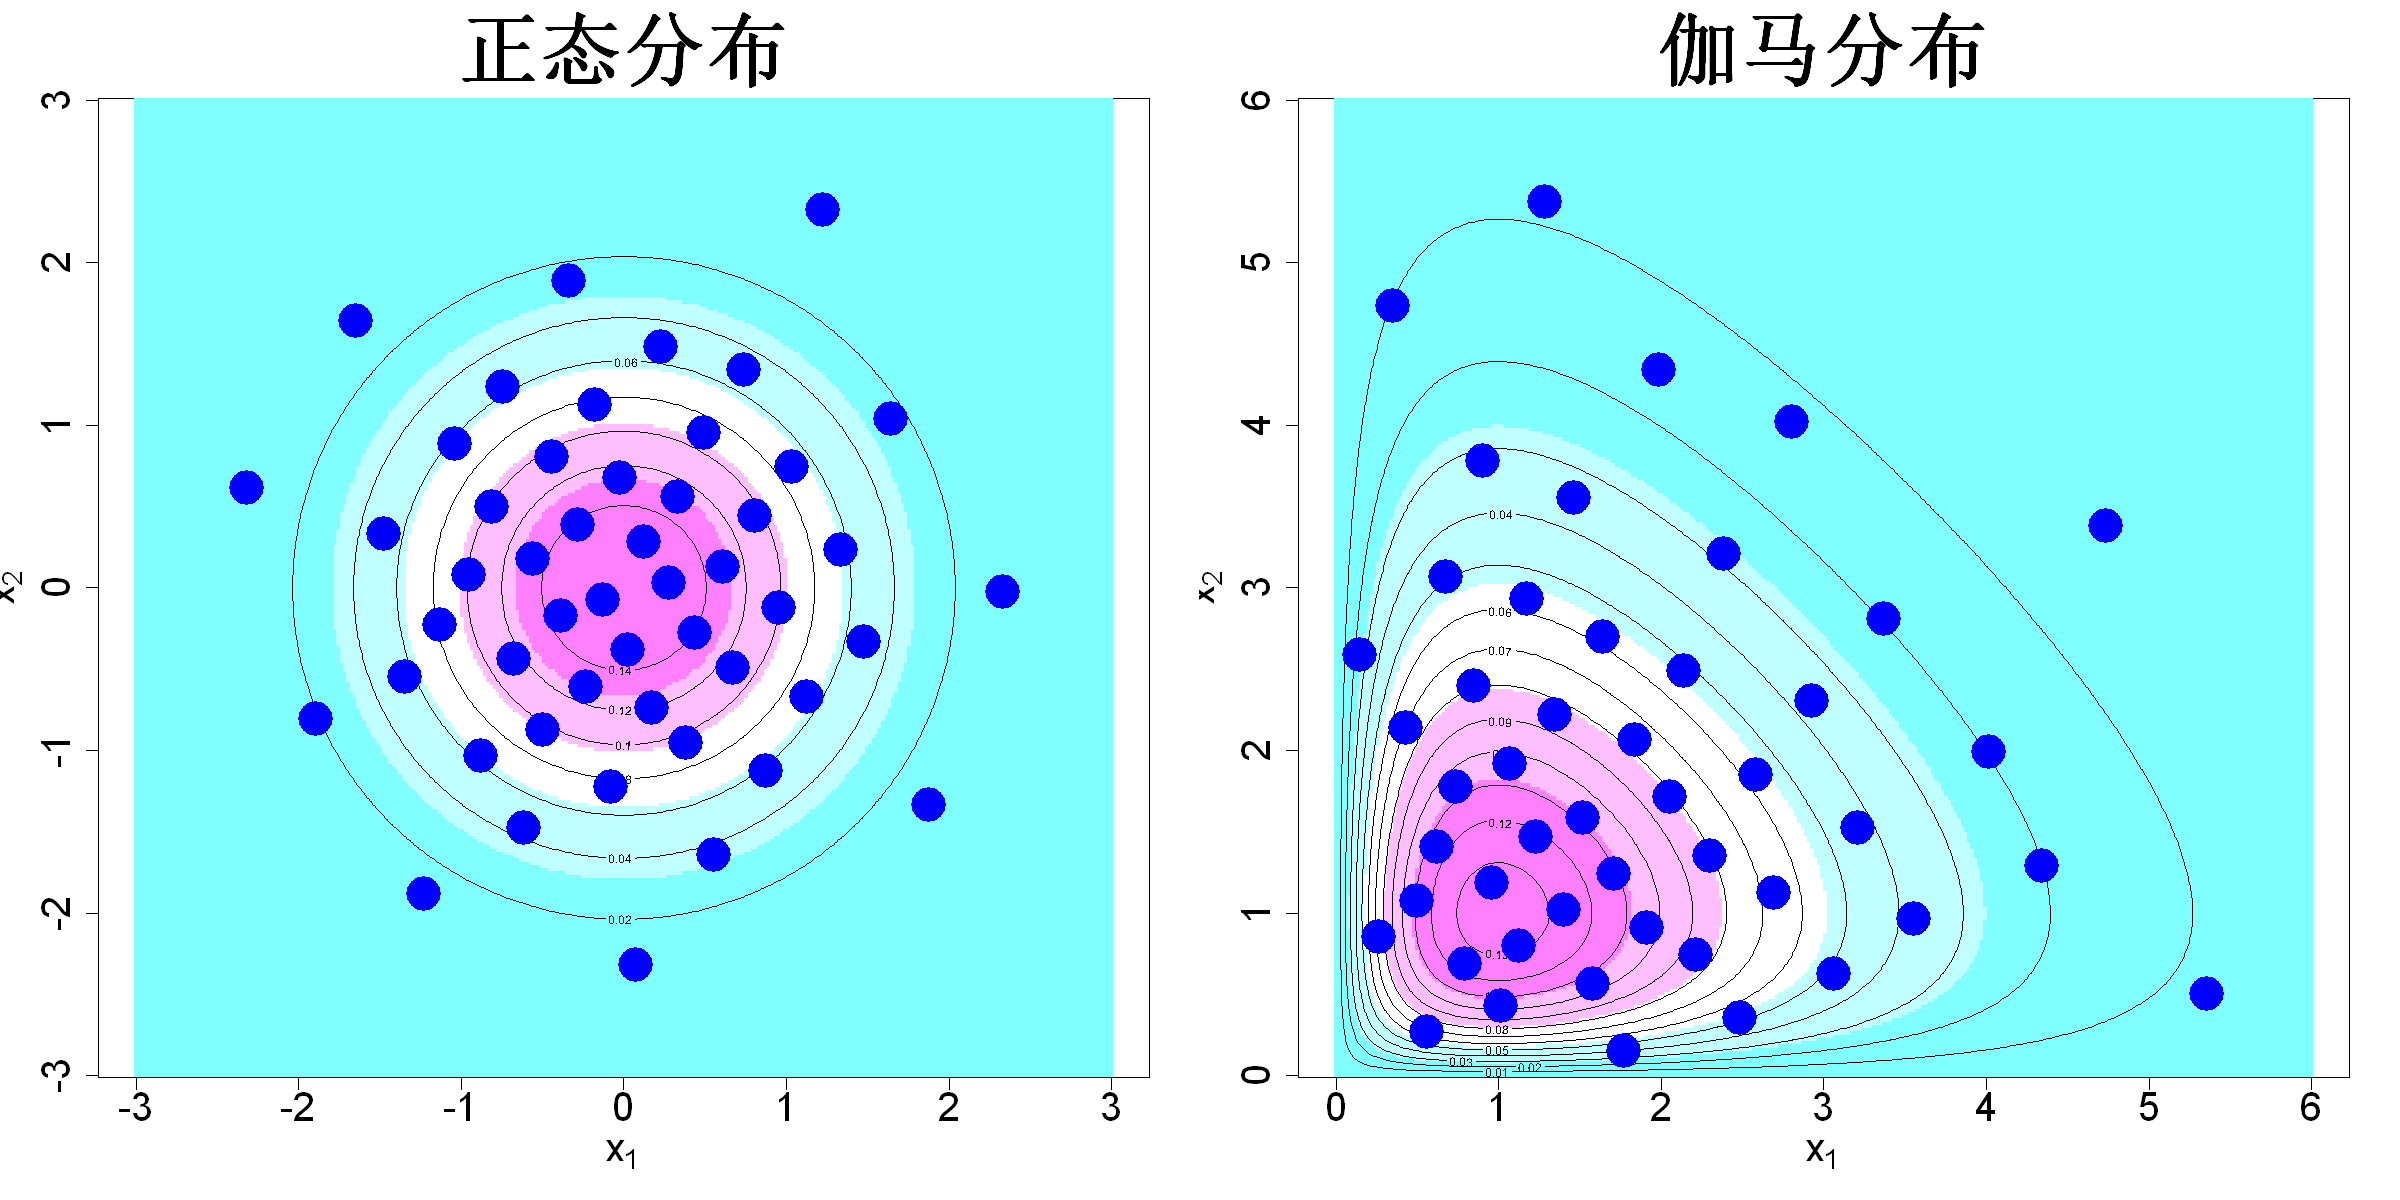

In [9]:
#图5.4

options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
p=2;n=50
set.seed(6)
library(SFDesign)
d=uniform.optim(uniformLHD(n,p)$design)$design
D=qnorm(d)
f=function(x)exp(-.5*sum(x^2))/(2*pi)
N.plot=300
p1=seq(-3,3,length.out=N.plot)
p2=seq(-3,3,length.out=N.plot)
fc=matrix(apply(expand.grid(p1,p2),1,f),nrow=N.plot,ncol=N.plot)
image(p1,p2,fc,cex.axis=2,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,col=cm.colors(5),main="正态分布",cex.main=4,asp=1)
contour(p1,p2,fc,add=TRUE,nlevels=10)
points(D,pch=16,col="blue",cex=4)

D=qgamma(d,2,1)
f=function(x)prod(dgamma(x,2,1))
N.plot=300
p1=seq(0,6,length.out=N.plot)
p2=seq(0,6,length.out=N.plot)
fc=matrix(apply(expand.grid(p1,p2),1,f),nrow=N.plot,ncol=N.plot)
image(p1,p2,fc,cex.axis=2,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,col=cm.colors(5),main="伽马分布",cex.main=4,asp=1)
contour(p1,p2,fc,add=TRUE,nlevels=10)
points(D,pch=16,col="blue",cex=4)
par(mfrow=c(1,1))

当变量之间存在相关性时,可使用罗森布拉特变换(1952):

$$\begin{aligned}u_1&=F_1(x_1)\\u_2&=F_2(x_2|x_1)\\&\vdots\\u_p&=F_p(x_p|x_1,\dots,x_{p-1})\end{aligned}$$

其中$F_i(x_i|x_1,\dots,x_{i-1})$是给定$x_1,\dots,x_{i-1}$时$x_i$的条件分布函数,且$u_i\stackrel{\mathrm{i.i.d.}}{\sim}\mathcal{U}(0,1)$.下面验证变换的合理性.该变换的雅可比行列式满足:

$$\begin{aligned}|J|&=\left|\frac{\partial(u_1,\dots,u_p)}{\partial(x_1,\dots,x_p)}\right|\\&=f_1(x_1)f_2(x_2|x_1)\cdots f_p(x_p|x_1,\dots,x_{p-1})\\&=f(x_1,x_2,\dots,x_p)\end{aligned}$$

由于雅可比矩阵是上三角矩阵,行列式等于对角线元素乘积.根据密度变换公式$f(x_1,\dots,x_p)=f_u(u_1,\dots,u_p)|J|$,可得$u_1,\dots,u_p$的联合概率密度恒等于1.举一个示例:构造服从下述二元正态分布的设计点:

$$\begin{bmatrix}x_1\\x_2\end{bmatrix}\sim\mathcal{N}_2\left(\begin{bmatrix}0\\0\end{bmatrix},\begin{bmatrix}1&\rho\\\rho&1\end{bmatrix}\right)\tag{5.8}$$

依据引理2.2可得:

$$\begin{aligned}x_1&\sim\mathcal{N}(0,1)\\x_2|x_1&\sim\mathcal{N}(\rho x_1,1-\rho^2)\end{aligned}$$

因此样本点可按如下方式生成:

$$\begin{aligned}x_{1i}&=\Phi^{-1}(u_{1i})\\x_{2i}&=\rho x_{1i}+\sqrt{1-\rho^2}\Phi^{-1}(u_{2i})\end{aligned}$$

$i=1,\dots,n$,其中$\{(u_{1i},u_{2i})\}_{i=1}^n$为均匀设计,$\Phi(\cdot)$是标准正态分布函数.图5.5展示了取$\rho=0.5$时生成的50个样本点,可以直观看到样本能够良好表征目标分布.

> **图5.5** 采用均匀设计经罗森布拉特变换得到的相关二元正态分布代表点,叠加绘制于分布灰度图之上

In [7]:
#图5.5

options(repr.plot.width=10,repr.plot.height=10)
p=2;n=50
set.seed(6)
library(SFDesign)
d=uniform.optim(uniformLHD(n,p)$design)$design
library(mnormt)
x1=qnorm(d[,1])
x2=qnorm(d[,2],mean=.5*x1,sd=sqrt(1-.5^2))
D=cbind(x1,x2)
f=function(x)dmnorm(x,mean=c(0,0),varcov=matrix(c(1,.5,.5,1),2,2))
N.plot=300
p1=seq(-3,3,length.out=N.plot)
p2=seq(-3,3,length.out=N.plot)
fc=matrix(apply(expand.grid(p1,p2),1,f),N.plot,N.plot)
image(p1,p2,fc,cex.axis=2,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,col=cm.colors(5),main="相关正态分布",cex.main=3,asp=1)
contour(p1,p2,fc,add=TRUE,nlevels=10)
points(D,pch=16,col="blue",cex=3)

方与王(1993)证明,罗森布拉特变换可用于在球体,单纯形内生成拟蒙特卡洛样本或均匀设计.但该变换难以适用于约束条件更加复杂的区域(如4.5.1节讨论的情形).此外,上述变换方法在其他统计问题中适用性有限.例如贝叶斯统计中,我们通常只能得到未归一化的后验密度,无法获取精确概率密度或分布函数;变量之间也可能存在相关性,条件分布形式未知.综上,一般情形下无法直接使用逆概率变换或罗森布拉特变换完成抽样.更棘手的场景是常规数据分析:仅有观测数据,对数据生成分布一无所知.因此我们需要一套更通用的,面向非均匀分布抽样的方法,相关内容在下一节介绍.